## Introduction to Affine transform


<img src="https://upload.wikimedia.org/wikipedia/commons/c/c4/Affine_transformations.gif?_=20140628205334" width="500" height="300" />

### How to calculate Affine transform matrix



o Rotation, Shift, and Resizing can be modeled by the following:

$
\begin{aligned}
\left[
\begin{matrix}
    x^{\prime}\\
    y^{\prime}
\end{matrix}
\right] =
\left[
\begin{matrix}
    \alpha_{11} & \alpha_{12}&\alpha_{13} \\
    \alpha_{21} & \alpha_{22}&\alpha_{23}
\end{matrix}
\right]
\left[
    \begin{matrix}
    x\\
    y\\
    1
\end{matrix}
\right]
\end{aligned}
$

    - We have 6 unknown variables and one point give us two equations

    - We need three points to determine the six unknown variables

o We can slightly change the above equation to caculate the affine matrix with six unknown variables

$
\begin{aligned}
\left[
\begin{matrix}
    x^{\prime}\\
    y^{\prime}\\
    1
\end{matrix}
\right] =
\left[
\begin{matrix}
    \alpha_{11} & \alpha_{12}&\alpha_{13} \\
    \alpha_{21} & \alpha_{22}&\alpha_{23} \\
        0       &           0&  1
\end{matrix}
\right]
\left[
    \begin{matrix}
    x\\
    y\\
    1
\end{matrix}
\right]
\end{aligned}
$

    - If we have three points, the following matrix equation is valid
$
\begin{aligned}
\left[ \begin{matrix}
    x_1^{\prime} & x_2^{\prime}&x_3^{\prime} \\
    y_1^{\prime} & y_2^{\prime}&y_3^{\prime}  \\
    1 & 1 & 1
\end{matrix}
\right]=
\left[
\begin{matrix}
    \alpha_{11} & \alpha_{12}&\alpha_{13} \\
    \alpha_{21} & \alpha_{22}&\alpha_{23} \\
        0       &           0&  1
\end{matrix}
\right]
\left[
\begin{matrix}
    x_1 & x_2&x_3 \\
    y_1 & y_2&y_3  \\
    1 & 1 & 1
\end{matrix}
\right]
\end{aligned}
$

    - Then, the affine matrix $A$ can be easily calculated

$
\begin{aligned}
A \left[
\begin{matrix}
    x_1 & x_2&x_3 \\
    y_1 & y_2&y_3  \\
    1 & 1 & 1
\end{matrix}
\right]
 = \left[ \begin{matrix}
    x_1^{\prime} & x_2^{\prime}&x_3^{\prime} \\
    y_1^{\prime} & y_2^{\prime}&y_3^{\prime}  \\
    1 & 1 & 1
\end{matrix}
\right]
\end{aligned}
$

$
\begin{aligned}
A = \left[ \begin{matrix}
    x_1^{\prime} & x_2^{\prime}&x_3^{\prime} \\
    y_1^{\prime} & y_2^{\prime}&y_3^{\prime}  \\
    1 & 1 & 1
\end{matrix} \right]  \left[ \begin{matrix}
    x_1 & x_2&x_3 \\
    y_1 & y_2&y_3  \\
    1 & 1 & 1
\end{matrix}
\right] ^{-1}
\end{aligned}
$

### <span style="color:red"> Note that the the first two elements in the 3rd (last) row are always zero.</span>

$\color{yellow}\boldsymbol{
\left[
\begin{matrix}
    \alpha_{11} & \alpha_{12}&\alpha_{13} \\
    \alpha_{21} & \alpha_{22}&\alpha_{23}
\end{matrix}
\right]
= \left[ \begin{matrix}
    x_1^{\prime} & x_2^{\prime}&x_3^{\prime} \\
    y_1^{\prime} & y_2^{\prime}&y_3^{\prime}
\end{matrix} \right]  \left[ \begin{matrix}
    x_1 & x_2&x_3 \\
    y_1 & y_2&y_3  \\
    1 & 1 & 1
\end{matrix}
\right] ^{-1}}
$

SRC:
[[200. 100.]
 [400. 100.]
 [200. 200.]]

DST:
[[200. 300.]
 [400. 200.]
 [200. 400.]]


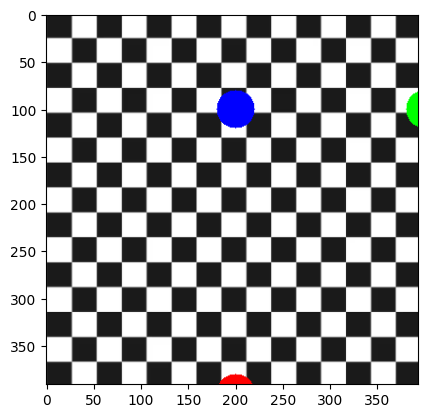

In [2]:
#-*- coding:utf-8 -*-
#%%
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

src = cv2.imread('../images/chessboard.png')

pts_src = np.float32([[200,100],[400,100],[200,200]]) # 점들의 좌표, cv2 는 xy 좌표 쓰는것에 주의
pts_dst = np.float32([[200,300],[400,200],[200,400]])


# pts_src의 좌표에 표시. Affine 변환 후 이동 점 확인.
cv2.circle(src, (200,100), 20, (255,0,0), -1)
cv2.circle(src, (400,100), 20, (0,255,0), -1)
cv2.circle(src, (200,400), 20, (0,0,255), -1)


print('SRC:')
print(pts_src)

print('\nDST:')
print(pts_dst)

plt.imshow(src[:,:,::-1])
plt.show()



먼저 src 랑 dst 를 3차원으로 만들고 z = 1 로 만들어줘야함

In [3]:
pts_dst_3d = pts_dst.transpose(1,0) # 먼저 (2,3) 으로 만듬
pts_dst_3d

array([[200., 400., 200.],
       [300., 200., 400.]], dtype=float32)

In [4]:
pts_src_3d = pts_src.transpose(1,0) # (2,3) 변환
pts_src_3d

array([[200., 400., 200.],
       [100., 100., 200.]], dtype=float32)

In [5]:
pts_src_3d = np.concatenate((pts_src_3d, np.ones((1,3))), axis=0) # z 축 추가
pts_src_3d

array([[200., 400., 200.],
       [100., 100., 200.],
       [  1.,   1.,   1.]])

In [6]:
pts_dst_3d = np.concatenate((pts_dst_3d, np.ones((1,3))), axis=0) # z축 추가
pts_dst_3d

array([[200., 400., 200.],
       [300., 200., 400.],
       [  1.,   1.,   1.]])

In [7]:
affine_mat_3d = pts_dst_3d @ np.linalg.inv(pts_src_3d) # src 의 역행렬 구해서 행렬곱해서 A 구함
affine_mat_3d

array([[ 1.00000000e+00,  4.16333634e-17,  0.00000000e+00],
       [-5.00000000e-01,  1.00000000e+00,  3.00000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

어파인 연산은 z 축에 잠깐 띄운 다음에 그대로 내리는거라 z 축이 필요가 딱히 없음 따라서 2d 여도 됨

In [8]:
affine_mat_2d = affine_mat_3d[:2]
affine_mat_2d 

array([[ 1.00000000e+00,  4.16333634e-17,  0.00000000e+00],
       [-5.00000000e-01,  1.00000000e+00,  3.00000000e+02]])

In [9]:
dst = np.zeros_like(src)
H, W = src.shape[:2]
for h in range(H):
    for w in range(W):
        src_pt = np.array([[w, h, 1]]).transpose(1,0)
        dst_pt = affine_mat_2d @ src_pt
        w_dst, h_dst = dst_pt
        w_dst, h_dst = int(w_dst[0]), int(h_dst[0])
        if 0<= w_dst < W and 0<= h_dst < H:
            dst[h_dst, w_dst] = src[h,w]

In [10]:
pts_dst

array([[200., 300.],
       [400., 200.],
       [200., 400.]], dtype=float32)

즉 src 점 3개 , dst 점 3개로 A 구해서 전체 이미지를 변환한다는 것임 

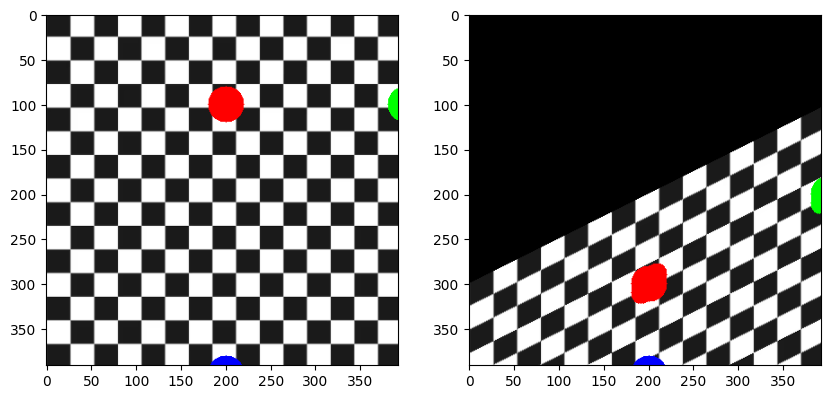

In [11]:

# pts_src의 좌표에 표시. Affine 변환 후 이동 점 확인.
cv2.circle(dst, (200,300), 20, (255,0,0), -1)
cv2.circle(dst, (400,200), 20, (0,255,0), -1)
cv2.circle(dst, (200,400), 20, (0,0,255), -1)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(src)
axes[1].imshow(dst)
plt.show()

In [12]:
pts_src1 = np.array[[]]

TypeError: 'builtin_function_or_method' object is not subscriptable